# Model building svm

## Word Embeddings (GloVe – Safe & Fast)

In [34]:
# Load GloVe embeddings (make sure 'glove.6B.50d.txt' is in your working directory)
embeddings_index = {}
with open('glove.6B.50d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector


In [34]:
import numpy as np

# Load GloVe 50D
embeddings_index = {}
with open('glove.6B.50d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector
print(f"Loaded {len(embeddings_index)} word vectors.")


Loaded 400000 word vectors.


In [35]:
import numpy as np
import pandas as pd

def text_to_avg_vector(text, embeddings_index, dim=50):
    words = text.split()
    vectors = [embeddings_index[word] for word in words if word in embeddings_index]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)

# Convert all cleaned text to average GloVe vectors
X_vectors = np.vstack([text_to_avg_vector(text, embeddings_index) for text in df['cleaned_text']])


In [36]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode sentiment labels
le = LabelEncoder()
y = le.fit_transform(df['Consolidated_Sentiment'])

In [ ]:
# Downsample each class to 5000 samples
df_temp = pd.DataFrame(X_vectors)
df_temp['target'] = y
df_balanced = df_temp.groupby('target', group_keys=False).apply(lambda x: x.sample(n=10000, random_state=42))


In [38]:
# Final balanced input and output
X_bal = df_balanced.drop('target', axis=1).values
y_bal = df_balanced['target'].values


In [39]:
# Split into train and test sets
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

In [40]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


In [ ]:
# Baseline SVM model with linear kernel
baseline_svm = make_pipeline(StandardScaler(), SVC(probability=True, kernel='linear'))
baseline_svm.fit(X_train_svm, y_train_svm)


In [62]:
# Predictions
y_pred_svm = baseline_svm.predict(X_test_svm)
y_proba_svm = baseline_svm.predict_proba(X_test_svm)

In [63]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("SVM Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
print("SVM F1 Score (Weighted):", f1_score(y_test_svm, y_pred_svm, average='weighted'))
print("SVM AUC:", roc_auc_score(y_test_svm, y_proba_svm, multi_class='ovr'))


SVM Accuracy: 0.6026666666666667
SVM F1 Score (Weighted): 0.5888998496939868
SVM AUC: 0.7649601666666667


## Text to Vectors (Average Word Embedding)


# Model Tuning Iteration 1

# Train-Test Split + Light Downsampling

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from collections import Counter

# Encode sentiment
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Consolidated_Sentiment'])

# Downsample each class to 5000 (safe for kernel)
df_temp = pd.DataFrame(X_vectors)
df_temp['target'] = y
df_balanced = df_temp.groupby('target', group_keys=False).apply(lambda x: x.sample(n=5000, random_state=42))

X_bal = df_balanced.drop('target', axis=1).values
y_bal = df_balanced['target'].values

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)


# Train SVM with Tuning (Light)

In [37]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_weighted', verbose=1)
grid.fit(X_train_svm, y_train_svm)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm',
                                        SVC(class_weight='balanced',
                                            probability=True))]),
             param_grid={'svm__C': [0.1, 1], 'svm__kernel': ['linear', 'rbf']},
             scoring='f1_weighted', verbose=1)

# Evaluation

In [38]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [39]:
# Predict
y_pred = grid.predict(X_test_svm)
y_proba = grid.predict_proba(X_test_svm)

In [41]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Accuracy
acc = accuracy_score(y_test_svm, y_pred)

# F1 Scores for multiclass
f1_macro = f1_score(y_test_svm, y_pred, average='macro')      # Treat all classes equally
f1_weighted = f1_score(y_test_svm, y_pred, average='weighted')  # Weighted by support

# AUC (if using predicted probabilities from a classifier that supports `predict_proba`)
auc = roc_auc_score(y_test_svm, y_proba, multi_class='ovr')


In [43]:
print("Accuracy:", acc)
print("F1 Score (Macro):", f1_macro)
print("F1 Score (Weighted):", f1_weighted)
print("AUC:", auc)


Accuracy: 0.6446666666666667
F1 Score (Macro): 0.6402663326434332
F1 Score (Weighted): 0.6402663326434334
AUC: 0.8015553333333334


Confusion Matrix (in numbers):
[[762  96 142]
 [283 493 224]
 [229  92 679]]


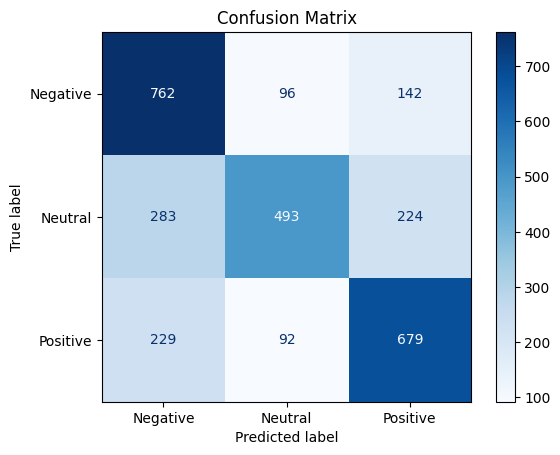

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test_svm, y_pred)

# Print as numbers
print("Confusion Matrix (in numbers):")
print(cm)

# Display as heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')  # 'd' = integer format
plt.title("Confusion Matrix")
plt.show()


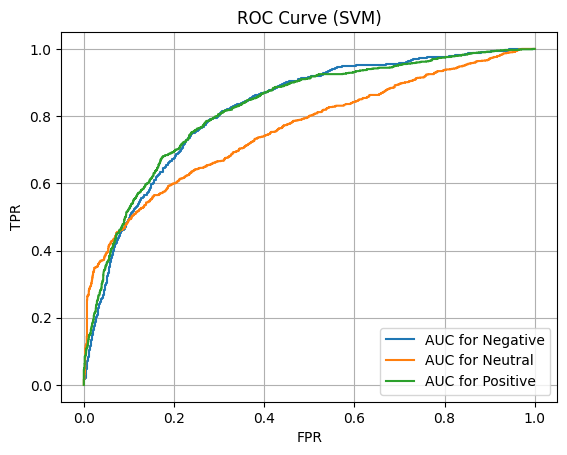

In [46]:
# AUC Plot (for 3 classes)
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_svm == i, y_proba[:, i])
    plt.plot(fpr, tpr, label=f"AUC for {le.classes_[i]}")
plt.legend()
plt.title("ROC Curve (SVM)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.show()

In [47]:
from sklearn.metrics import roc_auc_score

# For multiclass: One-vs-Rest AUC per class
for i in range(len(le.classes_)):
    y_true_binary = (y_test_svm == i).astype(int)
    y_score = y_proba[:, i]

    auc = roc_auc_score(y_true_binary, y_score)
    print(f"AUC for class '{le.classes_[i]}': {auc:.4f}")


AUC for class 'Negative': 0.8214
AUC for class 'Neutral': 0.7588
AUC for class 'Positive': 0.8244


## What was going wrong?

Default SVM with RBF kernel and default parameters. Model had moderate performance but likely suffered from class imbalance and suboptimal hyperparameters.

## Changes Made:

- Added `class_weight='balanced'` to handle class imbalance
- Increased `C` (regularization) to 10 to reduce underfitting
- Kept `kernel='rbf'`
